In [1]:
from fim import arules
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df_MBA_VA = pd.read_pickle('MBA_VA.pkl')
df_MBA_VA

,Title,Personnel_ID,Personnel_Name,Character
Anime_ID,,,,
1,Cowboy Bebop,"[10004, 10020, 10020, 10021, 10024, 10024, 100...","[Vasconcellos Jorge, Patiño Marco, Patiño Marc...","[Bob, Solensan, Asimov, Vicious, Spiegel, Spik..."
5,Cowboy Bebop: Tengoku no Tobira,"[10004, 10028, 10030, 10155, 10155, 1019, 1059...","[Vasconcellos Jorge, Atala Yamil, Ramirez Alfo...","[Bob, Spiegel, Spike, Black, Jet, Jobim, Anton..."
6,Trigun,"[10021, 1006, 1025, 1025, 10696, 1096, 1097, 1...","[Vilchis José Gilberto, Forstadt Rebecca, Magn...","[the Hornfreak, Midvalley, Elizabeth, Vash the..."
7,Witch Hunter Robin,"[10593, 1088, 1090, 10, 11920, 1268, 1286, 12,...","[Auer Dominik, Magnaghi Debora, Pacotto Emanue...","[Sakaki, Haruto, Sena, Robin, Doujima, Yurika,..."
8,Bouken Ou Beet,"[112, 1138, 145, 1526, 201, 201, 259, 357, 447...","[Midorikawa Hikaru, Cason Chri, Grant Tiffany,...","[Zenon, Grunide, Beet, Slade, Zenon, Shagi, Sh..."
...,...,...,...,...
61207,Tensei shitara Dragon no Tamago datta,[70],[Koshimizu Ami],[Voice of God]
61211,Mayonaka Heart Tune,[12041],[Ookubo Rumi],"[Himekawa, Nene]"
61227,Girls & Panzer: Motto Love Love Sakusen desu!,"[10765, 885, 9593]","[Kayano Ai, Iguchi Yuka, Fuchigami Mai]","[Takebe, Saori, Reizei, Mako, Nishizumi, Miho]"


## Check VA Team Sizes
#### The largest teams are...

In [3]:
df_MBA_VA.set_index('Title').Personnel_ID.apply(len).sort_values(ascending=False).head(20)

Title
One Piece                           1714
Naruto: Shippuuden                   828
Bleach                               730
Dragon Ball Z                        702
Naruto                               670
Pokemon Advanced Generation          471
Pokemon                              470
Pokemon Diamond & Pearl              453
Dragon Ball Super                    423
Fairy Tail                           423
Meitantei Conan                      416
Dragon Ball                          378
Fullmetal Alchemist: Brotherhood     365
InuYasha                             347
Inazuma Eleven                       344
Hunter x Hunter (2011)               344
Fullmetal Alchemist                  307
Pokemon (2019)                       288
Yuu☆Yuu☆Hakusho                      275
Dragon Ball GT                       268
Name: Personnel_ID, dtype: int64

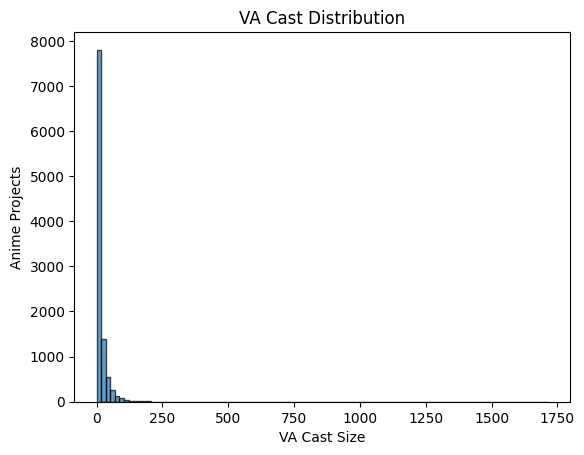

In [4]:
df_MBA_VA.Personnel_ID.apply(len).plot(kind='hist', bins=100, edgecolor='black', alpha=0.7)
plt.title('VA Cast Distribution')
plt.xlabel('VA Cast Size')
plt.ylabel('Anime Projects')
plt.show()

# What the Parameters mean

### Support
In how many anime projects, has the personnel **worked/appeared in**?

### Confidence
**Personnel B** Acceptance Rate

Given **Team A** is casted, what's the likelihood of **Personnel B** to accept?<br>
Compares the history of Team working with Personnel B.


### Lift
Colab chance vs Solo

How much more likely the colab is to push through than separate projects.

### Zmin
The final team size (Target hire + Required team).

In [5]:
def GenerateRules(MIN_PROJECTS = -20, ACCEPTANCE_RATE = 20, TEAM_SIZE = 5):
    report = 'bhaCL'
    header = ['Target_Hire', 'Required_Team', 'Projects_Taken(X)', 'Projects_Taken(Y)', 'Colab_Projects(X,Y)',  'Acceptance(Confidence%)', 'Colab(Lift%)']
    
    result = arules(df_MBA_VA['Personnel_ID'].to_list(), 
                    supp=MIN_PROJECTS, 
                    conf=ACCEPTANCE_RATE,
                    zmin = TEAM_SIZE,
                    report=report)
    
    df = pd.DataFrame(result, columns=header).sort_values('Colab(Lift%)', ascending=False)
    return df

In [6]:
def FilterRules(df_Rules : pd.DataFrame, EXISTING_CAST_IDS : tuple = None, TARGET_HIRE_ID : int = None):
    df_Filtered = df.copy()

    if TARGET_HIRE_ID is not None:
        df_Filtered = df_Filtered[df_Filtered['Target_Hire'] == TARGET_HIRE_ID]
        
    if EXISTING_CAST_IDS is not None:
        df_Filtered = df_Filtered[df_Filtered['Required_Team'].apply(lambda x: all(i in x for i in EXISTING_CAST_IDS))]
    
    return df_Filtered

In [7]:
df_Personnel_VA = pd.read_pickle('Personnels_VA.pkl')

In [8]:
def ContextualizeID(df_FilteredRules : pd.DataFrame):
    df_Result = pd.DataFrame()
    
    for p in (df_FilteredRules.Target_Hire,) + df_FilteredRules.Required_Team:
        df_Result = pd.concat([df_Result, df_Personnel_VA.loc[p][['Character', 'Title']].rename(index={'Character':df_Personnel_VA.loc[p].Personnel_Name}).apply(pd.Series).T], axis=1)
    
    return df_Result.T

## How It Works

Generate the Rules from all the Anime personnel lists:

<ol>
    <li> `MIN_PROJECTS` - Minimum number of Anime Projects the Team must have accomplished.</li>
    <li> `ACCEPTANCE_RATE` - Minimum likelihhod the Hire will accept, given the team.</li>
    <li> `TEAM_SIZE` - Minimum size of the Suggested Team + Hire.</li>
</ol>


In [9]:
df = GenerateRules(MIN_PROJECTS = -20, ACCEPTANCE_RATE = 20, TEAM_SIZE = 8)
df

,Target_Hire,Required_Team,Projects_Taken(X),Projects_Taken(Y),"Colab_Projects(X,Y)",Acceptance(Confidence%),Colab(Lift%)
4106479,12158,"(78, 1804, 313, 1602, 472, 253, 159)",20,4,4,20.0,51625.000000
4106486,12158,"(859, 659, 312, 313, 1602, 472, 189)",20,4,4,20.0,51625.000000
4106496,12158,"(650, 659, 312, 313, 472, 253, 159)",20,4,4,20.0,51625.000000
4108195,12024,"(557, 75, 673, 360, 202, 1108, 253)",20,4,4,20.0,51625.000000
4106482,12158,"(859, 659, 312, 472, 189, 253, 159)",20,4,4,20.0,51625.000000
...,...,...,...,...,...,...,...
3691601,159,"(517, 496, 831, 516, 481, 133, 14)",25,582,5,20.0,354.810997
3690898,159,"(517, 496, 831, 24, 481, 14, 128)",25,582,5,20.0,354.810997
3688456,159,"(517, 831, 24, 481, 133, 14, 128)",25,582,5,20.0,354.810997
3692258,159,"(517, 496, 831, 516, 24, 481, 14)",25,582,5,20.0,354.810997


## Filter for your needs 
#### Example on #160. Dio Wrio (Jojo) VA

<ol>
    <li>`df_Rules` - The generated rules dataframe</li>
    <li>`EXISTING_CAST_IDS` - [Optional] The current cast already possessed.</li>
    <li>`TARGET_HIRE_ID` - [Optional] A hire you're seeking.</li>
</ol>

In [10]:
df_Filtered = FilterRules(df, EXISTING_CAST_IDS=None, TARGET_HIRE_ID=160)
df_Filtered

,Target_Hire,Required_Team,Projects_Taken(X),Projects_Taken(Y),"Colab_Projects(X,Y)",Acceptance(Confidence%),Colab(Lift%)
26495,160,"(356, 158, 1804, 5626, 1047, 202, 672)",20,498,9,45.000000,932.981928
2566,160,"(872, 659, 312, 1602, 860, 472, 159)",24,498,9,37.500000,777.484940
2477,160,"(872, 312, 313, 1602, 860, 472, 159)",21,498,7,33.333333,691.097724
2683,160,"(872, 659, 312, 313, 1602, 860, 472)",21,498,7,33.333333,691.097724
2535,160,"(872, 659, 313, 1602, 860, 472, 159)",21,498,7,33.333333,691.097724
...,...,...,...,...,...,...,...
222596,160,"(1024, 678, 774, 1160, 128, 5033, 8609)",20,498,4,20.000000,414.658635
222361,160,"(1024, 678, 774, 1160, 128, 357, 8609, 1090, 1...",20,498,4,20.000000,414.658635
222362,160,"(1024, 678, 774, 1160, 128, 357, 8609, 1090, 1...",20,498,4,20.000000,414.658635
222512,160,"(1024, 678, 774, 1160, 128, 5033, 1108)",20,498,4,20.000000,414.658635


## Contextualize the IDs

First 2 rows is the Target Hire.
Succeeding are the other VAs.

In [11]:
ContextualizeID(df_Filtered.iloc[2])

,0,1,2,3,4,5,6,7,8,9,...,620,621,622,623,624,625,626,627,628,629
Koyasu Takehito,Takasugi Shinsuke,Fushiguro Touji,Shindou Ainosuke,Vasaago,Zeke,Takahashi Ryousuke,Barzini Finocchio,Hatakeyama,Mathers Roswaal L.,Hugh,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,3-nen Z-gumi Ginpachi-sensei,Jujutsu Kaisen: Kaigyoku/Gyokusetsu,SK∞ OVA: Extra Part,"S-Rank Monster no ""Behemoth"" dakedo, Neko to M...",Shingeki no Kyojin Movie: Kanketsu-hen - The L...,MF Ghost 2nd Season,"Saikyou no Shienshoku ""Wajutsushi"" de Aru Ore ...",Touhai: Ura Rate Mahjong Touhairoku,Re:Zero kara Hajimeru Isekai Seikatsu 3rd Season,Acro Trip,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Williams Kent,Go Gun-Hee,Higashi no Kaioshin,Rigurd,Rob,Sako Atsuhiro,Rigurd,Remerio Hans,Go Gun-Hee,Ishigami Byakuya,François Dole,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,Ore dake Level Up na Ken Season 2: Arise from ...,Dragon Ball Daima,Tensei shitara Slime Datta Ken: Kanwa - Lumino...,Shinigami Bocchan to Kuro Maid 3rd Season,Boku no Hero Academia: Memories,Tensei shitara Slime Datta Ken 3rd Season,Ookami to Koushinryou: Merchant Meets the Wise...,Ore dake Level Up na Ken,Dr. Stone: New World Part 2,Watashi no Oshi wa Akuyaku Reijou.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vale Eri,Hizutome Rakurou,Kurobee,Loki,Shigaraki Tomura,Shigaraki Tomura,Kurobee,Hizutome Rakurou,Godwin,Ryuuen Kakeru,Yamato,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,"Shangri-La Frontier: Kusoge Hunter, Kamige ni ...",Tensei shitara Slime Datta Ken: Kanwa - Lumino...,Fairy Tail: 100-nen Quest,Boku no Hero Academia 7th Season,Boku no Hero Academia: Memories,Tensei shitara Slime Datta Ken 3rd Season,"Shangri-La Frontier: Kusoge Hunter, Kamige ni ...",Shin no Nakama ja Nai to Yuusha no Party wo Oi...,Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu ...,Hametsu no Oukoku,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Glass Caitlin,Remia,Ashido Mina,Evergreen,Ashido Mina,Kusakabe Ryouko,Souka,Desmond Damian,Fengxian,Ashido Mina,Desmond Damian,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,Arifureta Shokugyou de Sekai Saikyou Season 3,Boku no Hero Academia the Movie 4: You're Next,Fairy Tail: 100-nen Quest,Boku no Hero Academia 7th Season,Date A Live V,Tensei shitara Slime Datta Ken 3rd Season,Spy x Family Movie: Code: White,Kusuriya no Hitorigoto,Boku no Hero Academia: UA Heroes Battle,Spy x Family Season 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tatum J Michael,Magma,Smith Erwin,Takahashi Ryousuke,Tendou Soun,Iida Tenya,Iida Tenya,Michaelis Sebastian,Kanon Azeschen Ledriano,Angart Zerceus,Kannazuki Kyouhei,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,Dr. Stone: Science Future,Shingeki no Kyojin Movie: Kanketsu-hen - The L...,MF Ghost 2nd Season,Ranma ½ (2024),Boku no Hero Academia the Movie 4: You're Next,Boku no Hero Academia 7th Season,Kuroshitsuji: Kishuku Gakkou-hen,Maou Gakuin no Futekigousha II: Shijou Saikyou...,Maou Gakuin no Futekigousha II: Shijou Saikyou...,Date A Live V,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Discussion
Currently, it's not a very helpful tool. 

It recommends based on history which would mean recasts in multiwork series and working with already established crews.

### Try adding Crew
Let's try adding a Director and form a crew based off that.